# Lower Imitation Random-Demand Scenario Debug

Use this before collecting expert data. Demand is fixed inside each generated scenario, but diverse across scenarios.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from local_a3_training_scenarios import generate_demand_curriculum
from lower_rl_training_utils import make_lower_env, extract_demand_load_matrix, set_current_upper_bias

SLICE_TYPES = ('eMBB', 'URLLC', 'mMTC')
SAFE_TOTAL_GNB_LOAD = 0.65
SAFE_SLICE_LOAD = 0.80
NUM_SCENARIOS = 81
DEMAND_SEED = 17

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = False

## Generate Scenario Curriculum

In [2]:
scenarios = generate_demand_curriculum(
    num_scenarios=NUM_SCENARIOS,
    demand_seed=DEMAND_SEED,
    safe_total_gnb_load=SAFE_TOTAL_GNB_LOAD,
    safe_slice_load=SAFE_SLICE_LOAD,
)
rows = []
for i, sc in enumerate(scenarios):
    meta = dict(sc.metadata)
    D = np.asarray(meta['demand_matrix'], dtype=float)
    for g in range(3):
        rows.append({
            'scenario': sc.name,
            'case_type': meta['case_type'],
            'gnb': f'gNB{g}',
            'total_load': D[g].sum(),
            **{SLICE_TYPES[s]: D[g, s] for s in range(3)},
        })
df = pd.DataFrame(rows)
display(df.head())
display(df.groupby('case_type')['scenario'].nunique().rename('count').reset_index())

,scenario,case_type,gnb,total_load,eMBB,URLLC,mMTC
0,random_demand_0000_balanced_41eada57fb,balanced,gNB0,0.6797,0.1824,0.2206,0.2767
1,random_demand_0000_balanced_41eada57fb,balanced,gNB1,0.8462,0.1934,0.3396,0.3132
2,random_demand_0000_balanced_41eada57fb,balanced,gNB2,0.7342,0.1859,0.2708,0.2775
3,random_demand_0001_single_slice_overload_0dfb0...,single_slice_overload,gNB0,0.2448,0.0519,0.0984,0.0945
4,random_demand_0001_single_slice_overload_0dfb0...,single_slice_overload,gNB1,0.5498,0.1747,0.2031,0.1720


,case_type,count
0,balanced,9
1,distributed_slice_overload,9
2,mixed_random,9
3,multi_slice_same_gnb_overload,9
4,no_feasible_target,9
5,risky_target_slice_load,9
6,risky_target_total_load,9
7,single_gnb_overload,9
8,single_slice_overload,9


## Demand Matrix Heatmaps

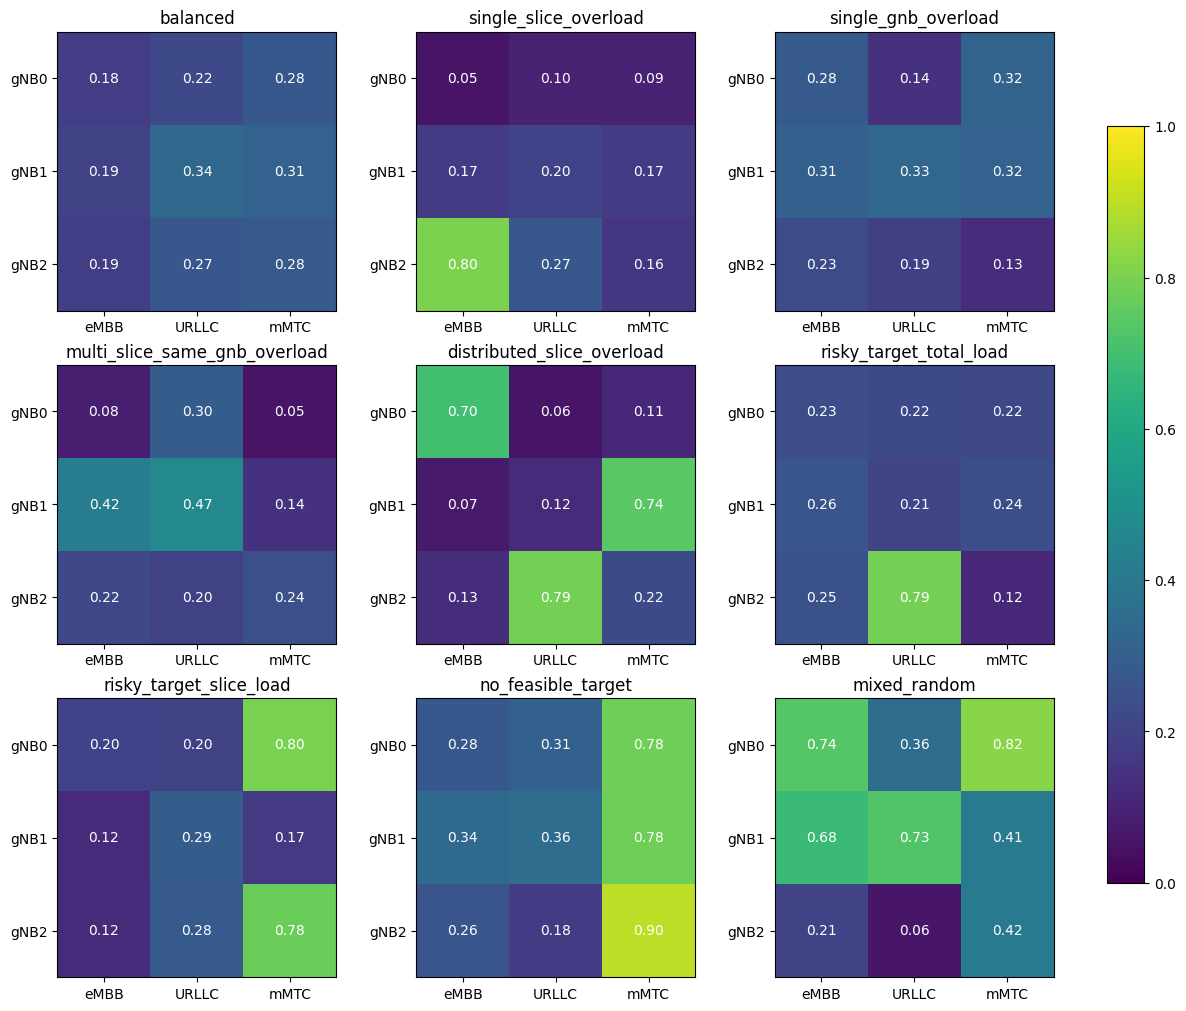

In [3]:
examples = []
seen = set()
for sc in scenarios:
    case = sc.metadata['case_type']
    if case not in seen:
        examples.append(sc)
        seen.add(case)
    if len(examples) >= 9:
        break

fig, axes = plt.subplots(3, 3, figsize=(12, 10), constrained_layout=True)
for ax, sc in zip(axes.ravel(), examples):
    D = np.asarray(sc.metadata['demand_matrix'], dtype=float)
    im = ax.imshow(D, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(sc.metadata['case_type'])
    ax.set_xticks(range(3), SLICE_TYPES)
    ax.set_yticks(range(3), [f'gNB{i}' for i in range(3)])
    for g in range(3):
        for s in range(3):
            ax.text(s, g, f'{D[g,s]:.2f}', ha='center', va='center', color='white')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()

## Load Distributions

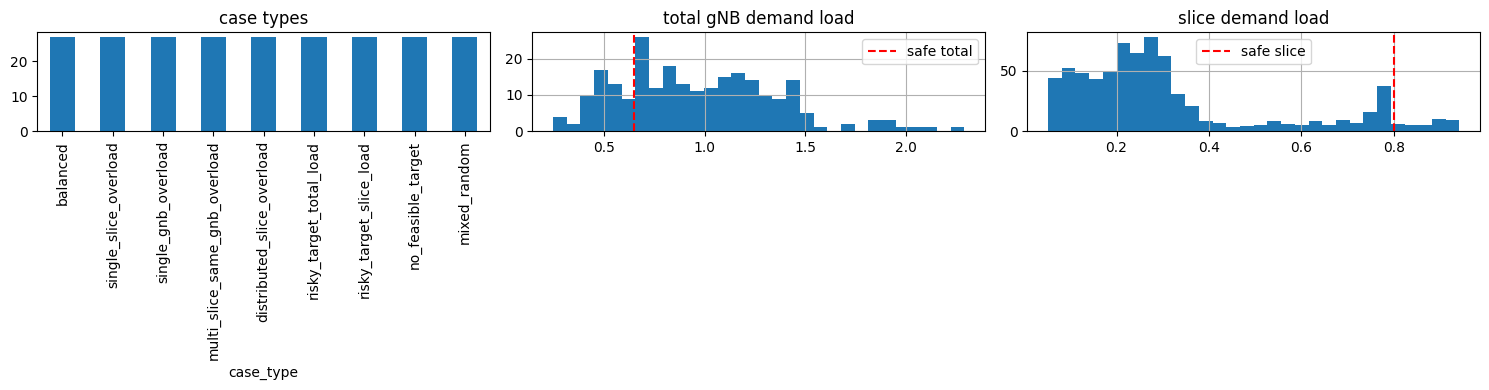

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['case_type'].value_counts().plot(kind='bar', ax=axes[0], title='case types')
df['total_load'].hist(bins=30, ax=axes[1])
axes[1].axvline(SAFE_TOTAL_GNB_LOAD, color='red', linestyle='--', label='safe total')
axes[1].set_title('total gNB demand load')
axes[1].legend()
pd.concat([df[s] for s in SLICE_TYPES]).hist(bins=30, ax=axes[2])
axes[2].axvline(SAFE_SLICE_LOAD, color='red', linestyle='--', label='safe slice')
axes[2].set_title('slice demand load')
axes[2].legend()
plt.tight_layout()
plt.show()

## Upper Bias Guard Checks

,episode,scenario,case_type,demand_source,total_g0,total_g1,total_g2,negative_bias_count,rejected_target_total_high
0,0,random_demand_0000_balanced_41eada57fb,balanced,upper_env._load_matrix,0.68,0.84,0.74,0,0
1,1,random_demand_0001_single_slice_overload_0dfb0...,single_slice_overload,upper_env._load_matrix,0.24,0.54,1.23,0,0
2,2,random_demand_0002_single_gnb_overload_c6b21c1e32,single_gnb_overload,upper_env._load_matrix,0.74,0.96,0.55,0,0
3,3,random_demand_0003_multi_slice_same_gnb_overlo...,multi_slice_same_gnb_overload,upper_env._load_matrix,0.43,1.03,0.66,0,0
4,4,random_demand_0004_distributed_slice_overload_...,distributed_slice_overload,upper_env._load_matrix,0.87,0.93,1.14,0,1


,negative_bias_count,rejected_target_total_high
case_type,,
balanced,0.00,0.00
distributed_slice_overload,0.00,1.56
mixed_random,0.00,1.56
multi_slice_same_gnb_overload,0.00,0.00
no_feasible_target,0.00,0.78
risky_target_slice_load,0.22,0.33
risky_target_total_load,0.11,0.33
single_gnb_overload,0.00,0.00
single_slice_overload,0.22,0.33


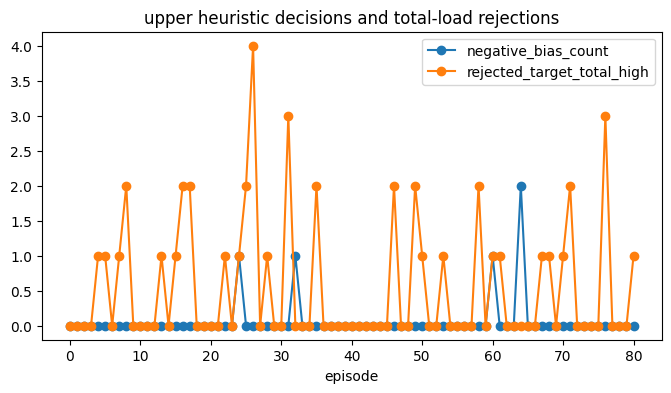

In [5]:
env = make_lower_env(
    scenario_mode='random_demand',
    num_random_scenarios=NUM_SCENARIOS,
    demand_seed=DEMAND_SEED,
    scenario_selection='cycle',
    episode_steps=8,
    print_scenarios=False,
)
records = []
try:
    for ep in range(NUM_SCENARIOS):
        obs, info = env.reset(seed=DEMAND_SEED + ep)
        D, source = extract_demand_load_matrix(env, info)
        bias = set_current_upper_bias(env, force=True)
        debug = getattr(env.base_env, '_last_upper_expert_debug', {})
        rejected = debug.get('rejected_target_total_high', []) if isinstance(debug, dict) else []
        records.append({
            'episode': ep,
            'scenario': info.get('scenario_name', env._current_scenario_name),
            'case_type': info.get('scenario_case_type', ''),
            'demand_source': source,
            'total_g0': D[0].sum(),
            'total_g1': D[1].sum(),
            'total_g2': D[2].sum(),
            'negative_bias_count': sum(1 for v in bias.values() if float(v) < 0),
            'rejected_target_total_high': len(rejected),
            'bias': bias,
            'rejected': rejected,
            'D': D.copy(),
        })
finally:
    env.close()

guard = pd.DataFrame([{k:v for k,v in r.items() if k not in ('bias','rejected','D')} for r in records])
display(guard.head())
display(guard.groupby('case_type')[['negative_bias_count','rejected_target_total_high']].mean().round(2))
ax = guard.plot(x='episode', y=['negative_bias_count','rejected_target_total_high'], marker='o')
ax.set_title('upper heuristic decisions and total-load rejections')
plt.show()

## Example: Slice Headroom Exists, Total Headroom Blocks Target

random_demand_0004_distributed_slice_overload_67369b225d distributed_slice_overload


,eMBB,URLLC,mMTC
gNB0,0.70,0.06,0.11
gNB1,0.07,0.12,0.74
gNB2,0.13,0.79,0.22


rejected examples:


,source_id,target_id,slice_type,reason,target_total_load,target_total_headroom,estimated_delta
0,2,1,URLLC,target_total_guard_margin,0.93,-0.28,0.2


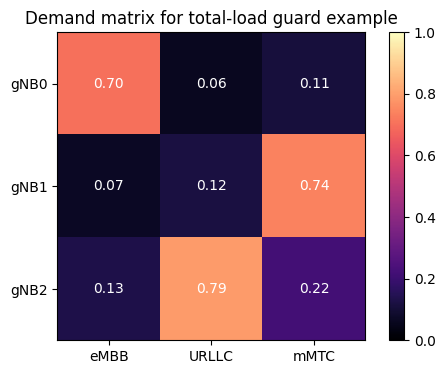

In [6]:
candidates = [r for r in records if r['rejected_target_total_high'] > 0]
if not candidates:
    print('No total-load-guard rejection found in this seed. Increase NUM_SCENARIOS or change DEMAND_SEED.')
else:
    r = candidates[0]
    D = r['D']
    print(r['scenario'], r['case_type'])
    display(pd.DataFrame(D, index=[f'gNB{i}' for i in range(3)], columns=SLICE_TYPES))
    print('rejected examples:')
    display(pd.DataFrame(r['rejected']).head(10))
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(D, vmin=0, vmax=1, cmap='magma')
    ax.set_xticks(range(3), SLICE_TYPES)
    ax.set_yticks(range(3), [f'gNB{i}' for i in range(3)])
    ax.set_title('Demand matrix for total-load guard example')
    for g in range(3):
        for s in range(3):
            ax.text(s, g, f'{D[g,s]:.2f}', ha='center', va='center', color='white')
    fig.colorbar(im, ax=ax)
    plt.show()

## Before/After Handover Demand Distribution

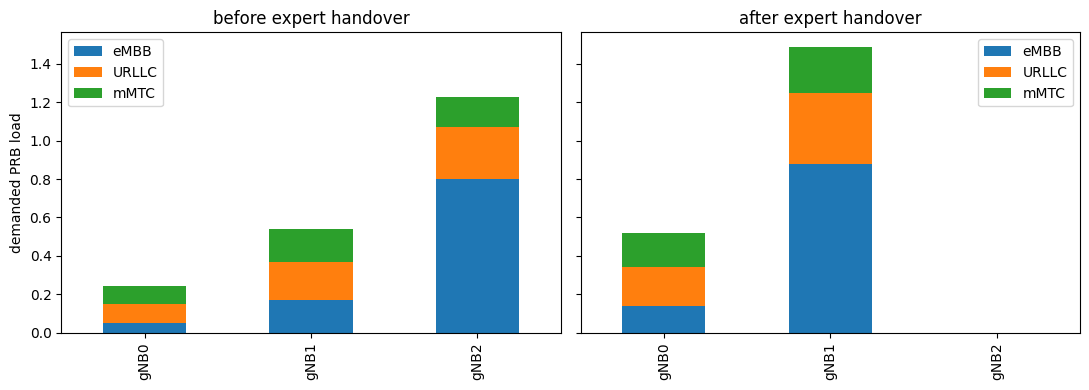

In [7]:
from lower_rl_training_utils import compute_expert_action

env = make_lower_env(
    scenario_mode='random_demand',
    num_random_scenarios=NUM_SCENARIOS,
    demand_seed=DEMAND_SEED,
    scenario_selection='random',
    episode_steps=8,
    print_scenarios=False,
)
try:
    obs, info = env.reset(seed=123)
    before, _ = extract_demand_load_matrix(env, info)
    bias = set_current_upper_bias(env, force=True)
    action, dbg = compute_expert_action(env, bias=bias, demand_load_matrix=before)
    obs, reward, terminated, truncated, info = env.step(action)
    after, _ = extract_demand_load_matrix(env, info)
finally:
    env.close()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, D, title in zip(axes, [before, after], ['before expert handover', 'after expert handover']):
    pd.DataFrame(D, index=[f'gNB{i}' for i in range(3)], columns=SLICE_TYPES).plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('demanded PRB load')
plt.tight_layout()
plt.show()